Imports and Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import random

In [2]:
random.seed(0)
np.random.seed(0)

Getting the Data

In [3]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

In [4]:
df = pd.read_csv(path+'/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Veryyyy Quick EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [8]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.drop('customerID', axis=1, inplace=True)

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.isnull().sum()


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.dropna(inplace=True)


Feature Engineering

In [13]:
df.Churn = (df['Churn'] == 'Yes').astype(int)


In [14]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = (
    df[service_cols]
    .apply(lambda col: col.map({'Yes': 1, 'No': 0, 
                                 'No internet service': 0,
                                 'No phone service': 0}))
    .sum(axis=1)
)


In [15]:
df['ChargePerService'] = df['MonthlyCharges'] / (df['TotalServices'] + 1)

df['ChargesTenureRatio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

df['TotalChargesExpected'] = df['MonthlyCharges'] * df['tenure']
df['ChargesGap'] = df['TotalChargesExpected'] - df['TotalCharges']

df['IsNewCustomer']    = (df['tenure'] <= 6).astype(int)
df['IsLoyalCustomer']  = (df['tenure'] >= 48).astype(int)

df['TenureBucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 mo', '6-12 mo', '12-24 mo', '24-48 mo', '48-72 mo']
)

# Tenure buckets as numeric ordinal
tenure_map = {'0-6 mo': 0, '6-12 mo': 1, '12-24 mo': 2, 
              '24-48 mo': 3, '48-72 mo': 4}
df['TenureScore'] = df['TenureBucket'].map(tenure_map)


In [16]:
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)

df['IsElectronicCheck'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

df['NoOnlineSecurity'] = (df['OnlineSecurity'] == 'No').astype(int)
df['NoTechSupport']    = (df['TechSupport'] == 'No').astype(int)

# Combined risk flag — month-to-month AND no security AND electronic check
df['HighRiskProfile'] = (
    (df['IsMonthToMonth'] == 1) &
    (df['NoOnlineSecurity'] == 1) &
    (df['IsElectronicCheck'] == 1)
).astype(int)

In [17]:
from sklearn.preprocessing import LabelEncoder

# Drop columns not useful for modeling
df.drop(columns=['TenureBucket'], inplace=True)

# Encode all remaining object columns
cat_cols = df.select_dtypes('object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAll categoricals encoded.")
print(f"Final shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")


Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All categoricals encoded.
Final shape: (7032, 33)
Missing values: 0


In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"\nChurn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.2f}%")

Training set:  (5625, 32)
Test set:      (1407, 32)

Churn rate in train: 26.58%
Churn rate in test:  26.58%


Model 1: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [22]:
model1 = LogisticRegression(max_iter = 1000,class_weight='balanced')
model1.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [23]:
pred_mod1 = model1.predict(X_test_scaled)

In [24]:
print(classification_report(y_test, pred_mod1,
      target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.91      0.74      0.82      1033
     Churned       0.53      0.80      0.64       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407



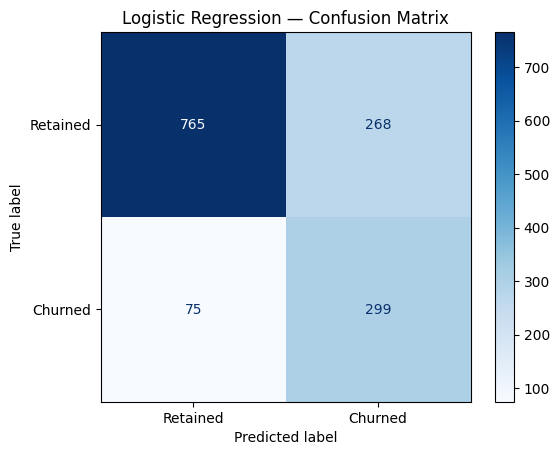

In [25]:
cm1 = confusion_matrix(y_test, pred_mod1)
ConfusionMatrixDisplay(cm1, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()


Model 2: Random Forest Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
model2 = RandomForestClassifier(class_weight='balanced', n_estimators = 5000)
model2.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [28]:
pred_mod2 = model2.predict(X_test_scaled)

In [29]:
print(classification_report(y_test, pred_mod2,
      target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.82      0.91      0.87      1033
     Churned       0.66      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



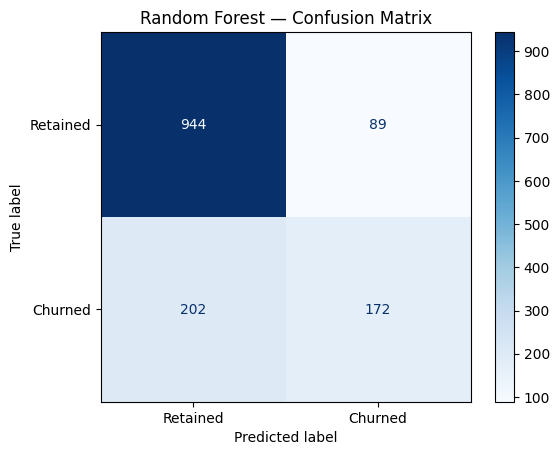

In [30]:
cm2 = confusion_matrix(y_test, pred_mod2)
ConfusionMatrixDisplay(cm2, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()


Model 3: XGBoost

In [31]:
from xgboost import XGBClassifier

In [32]:
model3 = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1,
    eval_metric='logloss'
)
model3.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [33]:
pred_mod3 = model3.predict(X_test_scaled)

In [34]:
print(classification_report(y_test, pred_mod3,
      target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.84      0.92      0.88      1033
     Churned       0.69      0.51      0.59       374

    accuracy                           0.81      1407
   macro avg       0.77      0.72      0.73      1407
weighted avg       0.80      0.81      0.80      1407



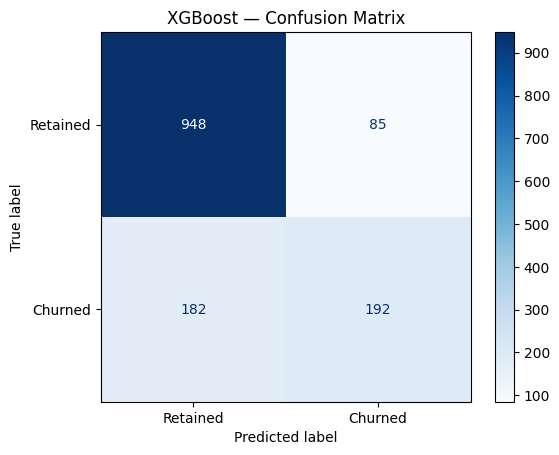

In [35]:
cm3 = confusion_matrix(y_test, pred_mod3)
ConfusionMatrixDisplay(cm3, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('XGBoost — Confusion Matrix')
plt.show()


Model 4: SVM

In [25]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

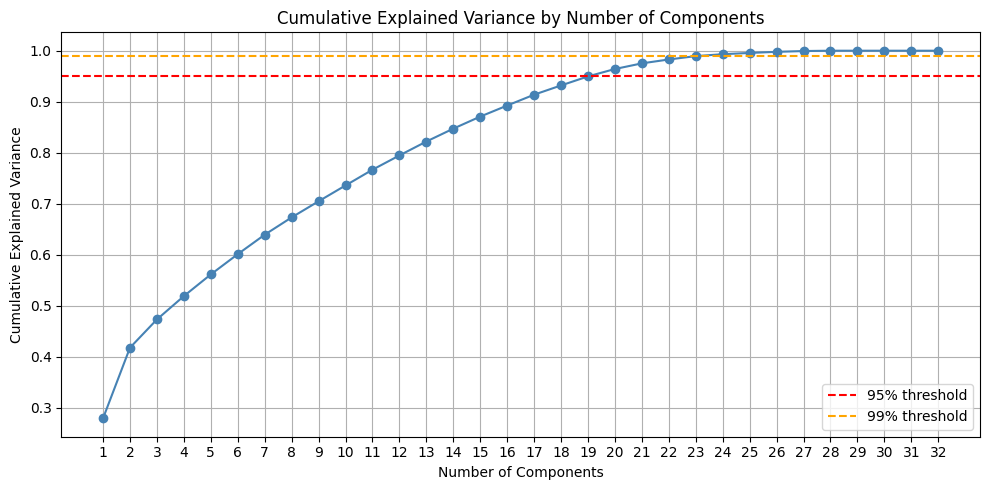

In [26]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 33), pca_full.explained_variance_ratio_.cumsum(), 
         marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 33))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
linear_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=0)),
    ('svm', SVC(kernel='linear', random_state=0, probability=True))
])

param_grid_linear_pca = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_linear_pca = GridSearchCV(linear_pca_pipeline, param_grid_linear_pca, 
                                cv=5, scoring='accuracy', verbose=1)
grid_linear_pca.fit(X_train_scaled, y_train)

best_linear_pca = grid_linear_pca.best_estimator_

print("Best C:", grid_linear_pca.best_params_['svm__C'])
print("Best CV Accuracy: {:.3f}".format(grid_linear_pca.best_score_))
print("\nNumber of components selected:", 
      best_linear_pca.named_steps['pca'].n_components_)

print("Linear SVM + PCA — Test:")
print(classification_report(y_test, best_linear_pca.predict(X_test_scaled), target_names=['Retained', 'Churned']))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: 100
Best CV Accuracy: 0.793

Number of components selected: 20
Linear SVM + PCA — Test:
              precision    recall  f1-score   support

    Retained       0.81      0.92      0.86      1033
     Churned       0.65      0.42      0.51       374

    accuracy                           0.79      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



In [28]:
rbf_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('svm', SVC(kernel='rbf', random_state=42, probability=True))
])

param_grid_rbf_pca = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

grid_rbf_pca = GridSearchCV(rbf_pca_pipeline, param_grid_rbf_pca,
                              cv=5, scoring='accuracy', verbose=1)
grid_rbf_pca.fit(X_train_scaled, y_train)

best_rbf_pca = grid_rbf_pca.best_estimator_

print("Best C:", grid_rbf_pca.best_params_['svm__C'])
print("Best Gamma:", grid_rbf_pca.best_params_['svm__gamma'])
print("Best CV Accuracy: {:.3f}".format(grid_rbf_pca.best_score_))

print("RBF SVM + PCA — Test:")
print(classification_report(y_test, best_rbf_pca.predict(X_test_scaled), target_names=['Retained', 'Churned']))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best C: 1
Best Gamma: 0.01
Best CV Accuracy: 0.797
RBF SVM + PCA — Test:
              precision    recall  f1-score   support

    Retained       0.82      0.92      0.87      1033
     Churned       0.67      0.46      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



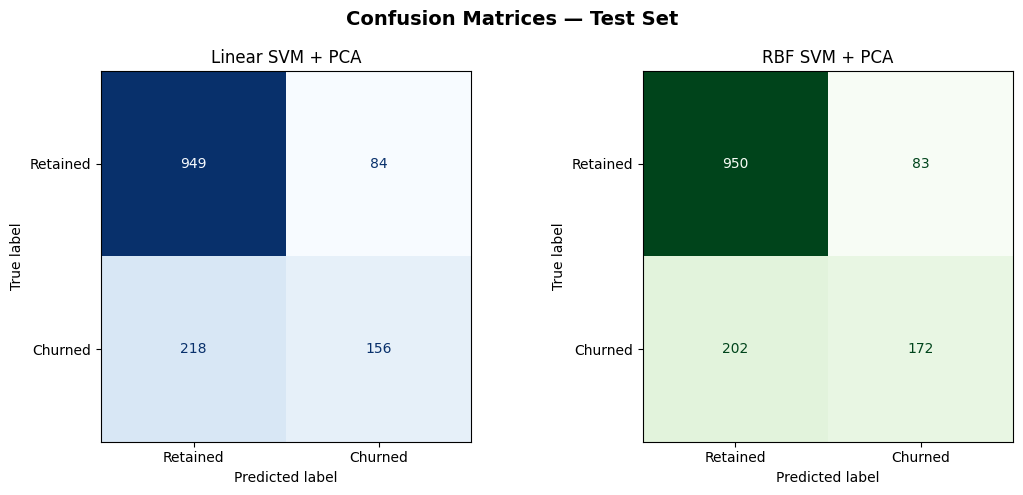

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (11,5))

models_list = [
    (best_linear_pca, 'Linear SVM + PCA', 'Blues'),
    (best_rbf_pca, 'RBF SVM + PCA', 'Greens'),
]

for ax, (model, title, cmap) in zip(axes, models_list):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Retained','Churned'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Model 5: Enter Neural Nets

In [41]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(0)

# Class weights to handle churn imbalance (~26% churn)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}


In [42]:
def build_classifier():
    model = Sequential([
        Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

In [43]:
model_nn = build_classifier()
print(model_nn.summary())

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=20,
    mode='max',            
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 128 (512.00 B)

None
Epoch 1/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6718 - auc: 0.7462 - loss: 0.9261 - val_accuracy: 0.7289 - val_auc: 0.8185 - val_loss: 0.5296
Epoch 2/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.7209 - auc: 0.8073 - loss: 0.8071 - val_accuracy: 0.7236 - val_auc: 0.8261 - val_loss: 0.5141
Epoch 3/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.7304 - auc: 0.8185 - loss: 0.7797 - val_accuracy: 0.7307 - val_auc: 0.8280 - val_loss: 0.5049
Epoch 4/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.7427 - auc: 0.8279 - loss: 0.7621 - val_accuracy: 0.7298 - val_auc: 0.8278 - val_loss: 0.5009
Epoch 5/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.7404 - auc: 0.8309 - loss: 0.7518 - val_accuracy: 0.7342 - val_auc: 0.8303 - val_loss: 0.5001
Epoch 6/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - accuracy: 0.7438 - auc: 0.8399 - loss: 0.7328 - val_accuracy: 0.7298 - val_auc: 0.8315 - val_loss: 0.5048
Epoch 7/200
71/71 ━━━━━━━━━━━━━

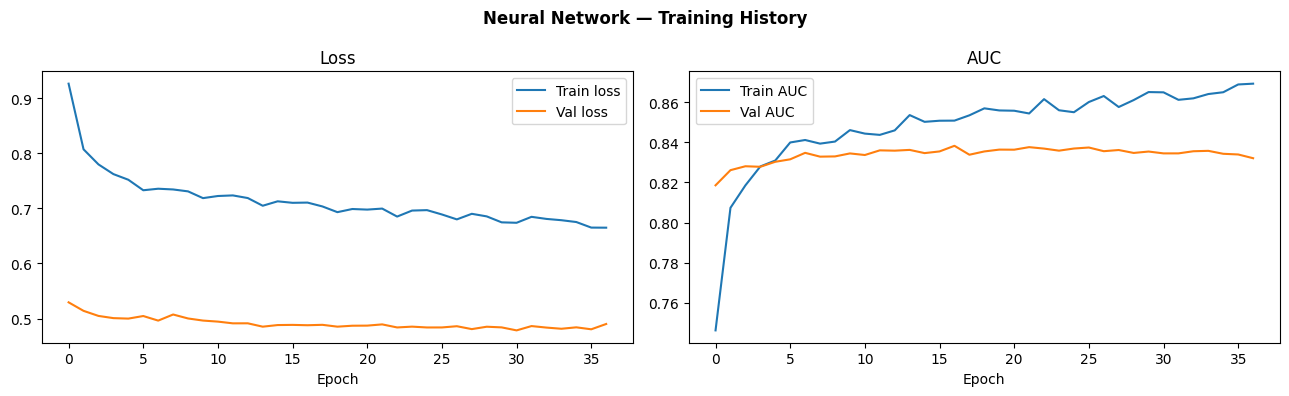

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Neural Network — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
pred_nn_proba = model_nn.predict(X_test_scaled).flatten()
pred_nn = (pred_nn_proba > 0.5).astype(int)

print(classification_report(y_test, pred_nn, target_names=['Retained', 'Churned']))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step
              precision    recall  f1-score   support

    Retained       0.91      0.75      0.82      1033
     Churned       0.53      0.79      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407



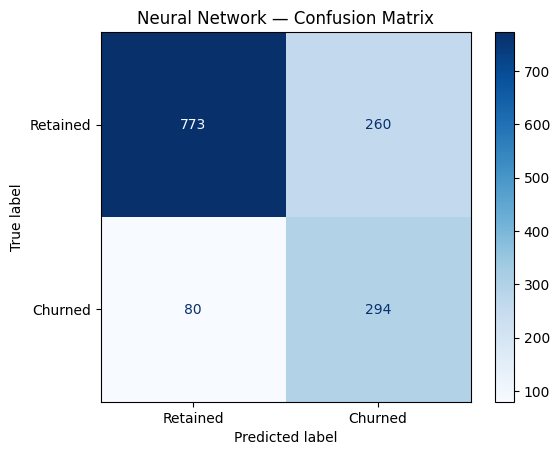

In [46]:
cm5 = confusion_matrix(y_test, pred_nn)
ConfusionMatrixDisplay(cm5, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('Neural Network — Confusion Matrix')
plt.show()


AUC-ROC Curves

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step


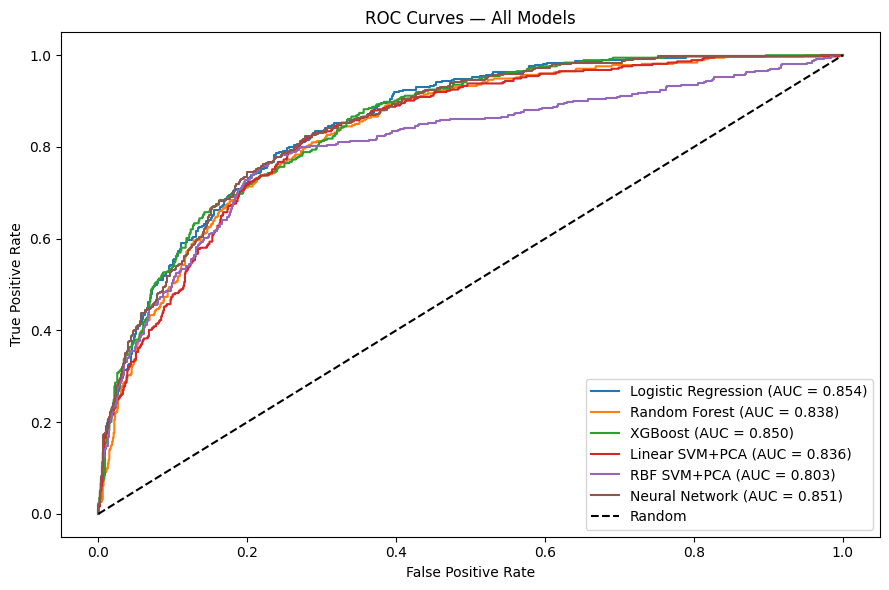

In [50]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': (model1, X_test_scaled),
    'Random Forest':       (model2, X_test_scaled),
    'XGBoost':             (model3, X_test_scaled),
    'Linear SVM+PCA':      (best_linear_pca, X_test_scaled),
    'RBF SVM+PCA':         (best_rbf_pca, X_test_scaled)
}

plt.figure(figsize=(9, 6))
for name, (model, X) in models.items():
    proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') \
            else model.decision_function(X)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

nn_proba = model_nn.predict(X_test_scaled).flatten()
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_proba)
auc_nn = roc_auc_score(y_test, nn_proba)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})')


plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()